<a href="https://colab.research.google.com/github/subuhang/AI-and-Machine-Learning/blob/main/Language_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Install required packages. Run once in Google Colab.
!pip -q install contractions wordcloud gensim gradio


In [18]:
import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
import contractions

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
GPU available: True


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Load and review the dataset

In [19]:
import pandas as pd

DATA_PATH = '/content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Hotel_Reviews.csv'

df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
display(df.head())

print('\nColumns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isna().sum())

print('\nRating distribution:')
print(df['Rating'].value_counts().sort_index())

Dataset shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5



Columns:
['Review', 'Rating']

Missing values:
Review    0
Rating    0
dtype: int64

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Keep only required columns and remove duplicates if present.
df = df[['Review', 'Rating']].copy()
df = df.dropna(subset=['Review', 'Rating'])
df = df.drop_duplicates(subset=['Review']).reset_index(drop=True)

# Convert numerical ratings into sentiment labels.
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Rating'].apply(rating_to_sentiment)

print('Shape after cleaning missing/duplicate rows:', df.shape)

print('\nSentiment distribution:')
print(df['sentiment'].value_counts())

print('\nSentiment percentage:')
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))

display(df.head())

Shape after cleaning missing/duplicate rows: (20491, 3)

Sentiment distribution:
sentiment
positive    15093
negative     3214
neutral      2184
Name: count, dtype: int64

Sentiment percentage:
sentiment
positive    73.66
negative    15.68
neutral     10.66
Name: proportion, dtype: float64


,Review,Rating,sentiment
0,nice hotel expensive parking got good deal sta...,4,positive
1,ok nothing special charge diamond member hilto...,2,negative
2,nice rooms not 4* experience hotel monaco seat...,3,neutral
3,"unique, great stay, wonderful time hotel monac...",5,positive
4,"great stay great stay, went seahawk game aweso...",5,positive


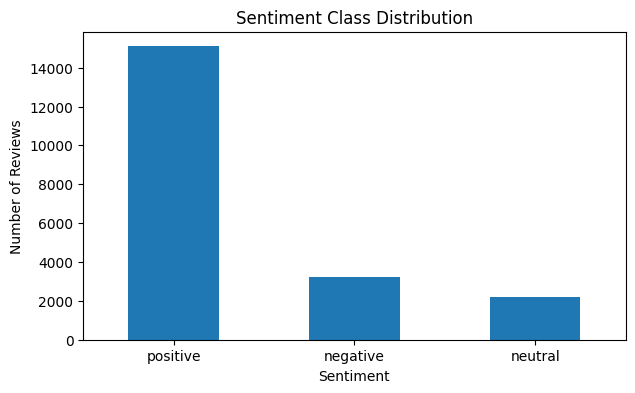

count    20491.000000
mean       104.375824
std        100.656586
min          7.000000
50%         77.000000
75%        124.000000
90%        201.000000
95%        275.000000
99%        502.000000
max       1931.000000
Name: Review, dtype: float64


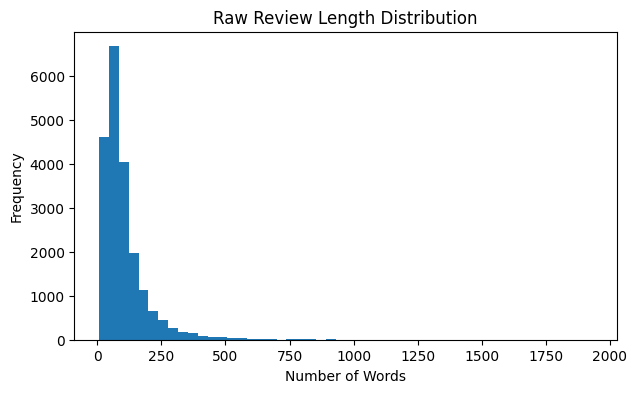

In [22]:
plt.figure(figsize=(7,4))
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

review_lengths = df['Review'].astype(str).str.split().str.len()
print(review_lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(7,4))
plt.hist(review_lengths, bins=50)
plt.title('Raw Review Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


## 2. Text preprocessing

Steps applied:

1. Lowercase text
2. Expand contractions
3. Remove URLs, mentions, hashtags, numbers, and special characters
4. Remove stopwords
5. Lemmatize words


In [23]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Keep negation words because they are important in sentiment analysis.
for word in ['no', 'not', 'nor', 'never']:
    stop_words.discard(word)


def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)      # URLs
    text = re.sub(r'@\w+', ' ', text)                # mentions
    text = re.sub(r'#', ' ', text)                    # hashtag symbol
    text = re.sub(r'[^a-z\s]', ' ', text)            # numbers and special characters
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

start = time.time()
df['clean_review'] = df['Review'].apply(clean_text)
print('Cleaning completed in seconds:', round(time.time() - start, 2))
display(df[['Review', 'clean_review', 'sentiment']].head())


Cleaning completed in seconds: 13.73


,Review,clean_review,sentiment
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,positive
1,ok nothing special charge diamond member hilto...,nothing special charge diamond member hilton d...,negative
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...,neutral
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,positive
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,positive


In [24]:
# Remove rows that became empty after preprocessing.
df = df[df['clean_review'].str.strip() != ''].reset_index(drop=True)
print('Final dataset shape:', df.shape)


Final dataset shape: (20491, 4)


## 3. Visualize cleaned data

,word,count
0,hotel,54048
1,room,47779
2,not,34006
3,great,21485
4,good,17492
5,staff,16706
6,stay,15601
7,night,14577
8,day,13484
9,time,12981


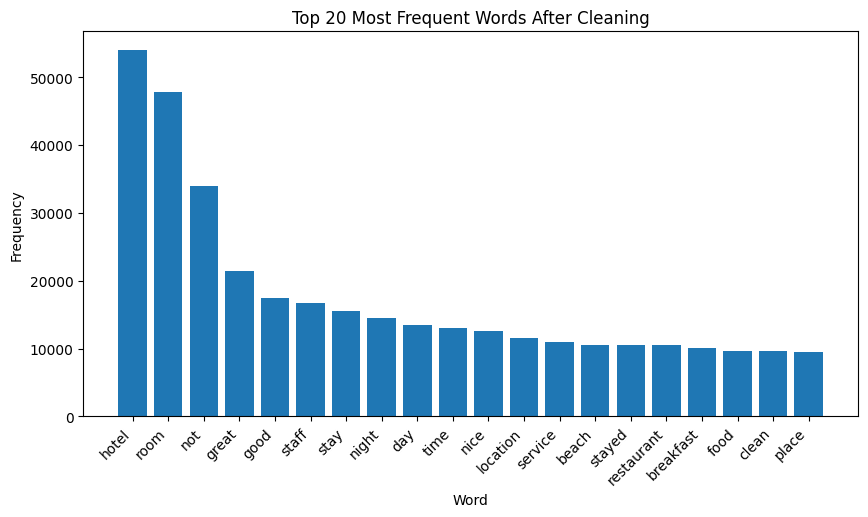

In [25]:
all_words = ' '.join(df['clean_review']).split()
word_freq = Counter(all_words)
most_common = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
display(most_common)

plt.figure(figsize=(10,5))
plt.bar(most_common['word'], most_common['count'])
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()


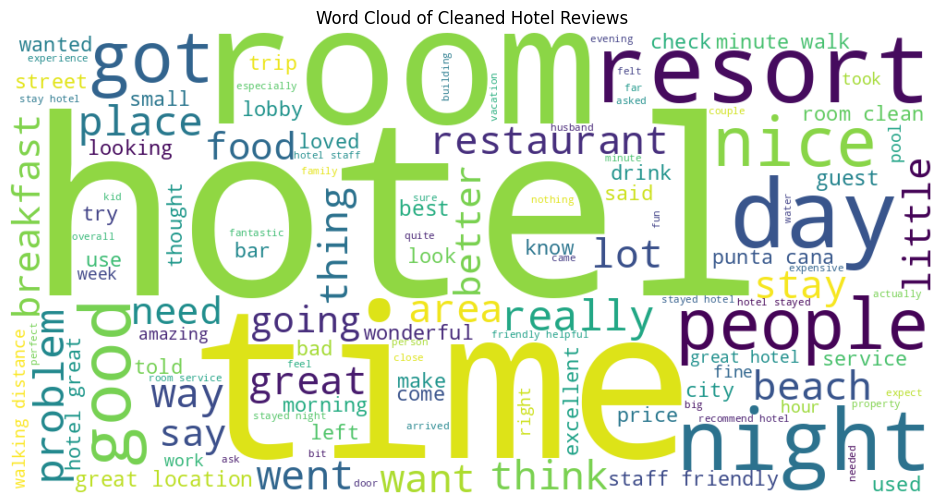

In [26]:
wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=120).generate(' '.join(df['clean_review']))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Hotel Reviews')
plt.show()


## 4. Train-test split, tokenization, and percentile-based padding

In [27]:
X = df['clean_review'].values
y = df['sentiment'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print('Classes:', class_names)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

MAX_WORDS = 20000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Percentile-based padding avoids using the extreme maximum review length.
train_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(train_lengths, 95))
MAX_LEN = max(MAX_LEN, 10)
print('95th percentile sequence length:', MAX_LEN)

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocabulary size used:', vocab_size)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


Classes: ['negative', 'neutral', 'positive']
95th percentile sequence length: 256
Vocabulary size used: 20000
X_train shape: (16392, 256)
X_test shape: (4099, 256)


In [28]:
# Class weights help address the strong imbalance toward positive reviews.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}
print('Class weights:', class_weights)


Class weights: {0: np.float64(2.1252430960715674), 1: np.float64(3.1276473955352033), 2: np.float64(0.4525426536359119)}


## 5. Helper functions for model training and evaluation

In [30]:
def plot_history(history, model_name):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name}: Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name}: Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)

    print(f'\n{model_name} Accuracy: {acc:.4f}')

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f'{model_name}: Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return acc, y_pred


callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

EPOCHS = 12
BATCH_SIZE = 64
EMBEDDING_DIM = 128

## 6. Model 1 - Simple RNN with trainable Embedding layer

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3282 - loss: 1.1085 - val_accuracy: 0.2495 - val_loss: 1.1104 - learning_rate: 0.0010
Epoch 2/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3603 - loss: 1.0954 - val_accuracy: 0.3989 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 3/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3863 - loss: 1.0840 - val_accuracy: 0.2614 - val_loss: 1.1136 - learning_rate: 0.0010
Epoch 4/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4322 - loss: 1.0717 - val_accuracy: 0.1077 - val_loss: 1.1318 - learning_rate: 0.0010
Epoch 5/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4259 - loss: 1.0528 - val_accuracy: 0.1107 - val_loss: 1.1131 - learning_rate: 5.0000e-04


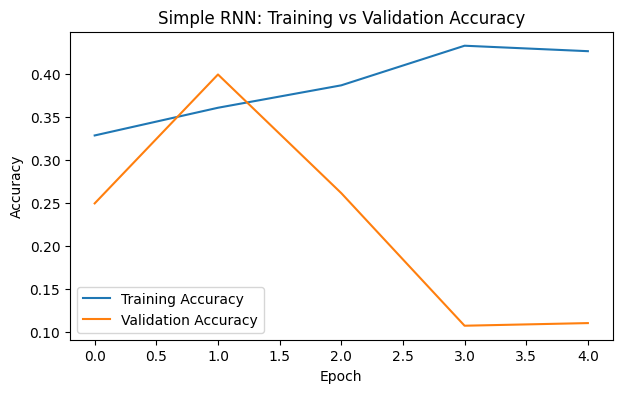

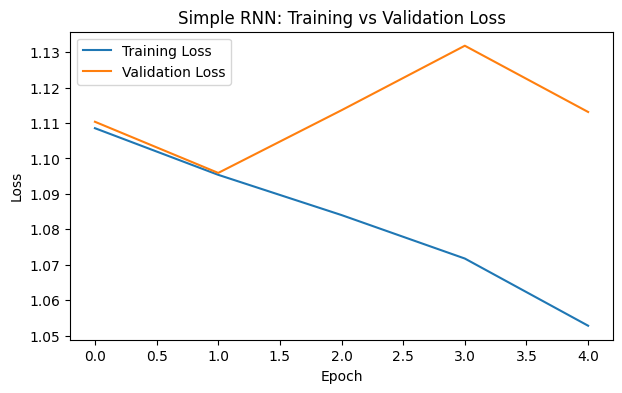


Simple RNN Accuracy: 0.3864

Classification Report:
              precision    recall  f1-score   support

    negative       0.14      0.12      0.13       643
     neutral       0.10      0.42      0.17       437
    positive       0.74      0.44      0.55      3019

    accuracy                           0.39      4099
   macro avg       0.33      0.33      0.28      4099
weighted avg       0.58      0.39      0.44      4099



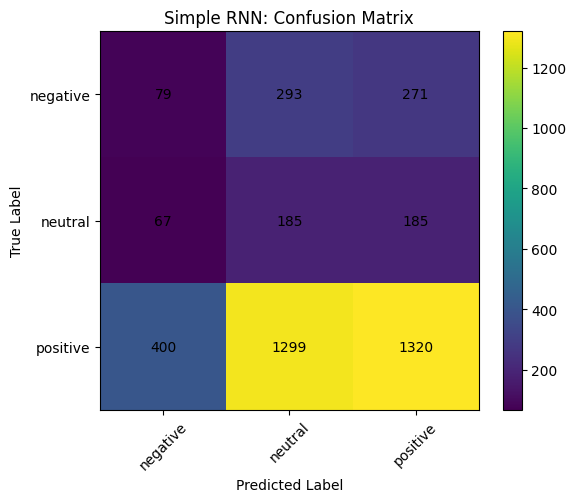

Training time seconds: 35.37


In [31]:
def build_rnn_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

start = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)
rnn_time = time.time() - start

plot_history(rnn_history, 'Simple RNN')
rnn_acc, rnn_pred = evaluate_model(rnn_model, X_test, y_test, 'Simple RNN')
print('Training time seconds:', round(rnn_time, 2))


## 7. Model 2 - LSTM with trainable Embedding layer

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3400 - loss: 1.0990 - val_accuracy: 0.1092 - val_loss: 1.0947 - learning_rate: 0.0010
Epoch 2/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3672 - loss: 1.0972 - val_accuracy: 0.1116 - val_loss: 1.1063 - learning_rate: 0.0010
Epoch 3/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4287 - loss: 1.1042 - val_accuracy: 0.1156 - val_loss: 1.0807 - learning_rate: 0.0010
Epoch 4/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3934 - loss: 1.0728 - val_accuracy: 0.1214 - val_loss: 1.1086 - learning_rate: 0.0010
Epoch 5/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4374 - loss: 1.0512 - val_accuracy: 0.1275 - val_loss: 1.1262 - learning_rate: 0.0010
Epoch 6/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4676 - loss: 1.0379 - val_accuracy: 0.1260 - val_loss: 1.1233 - learning_rate: 5.0000e-04


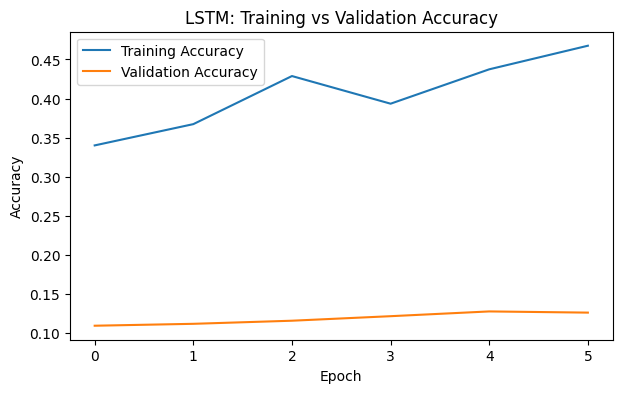

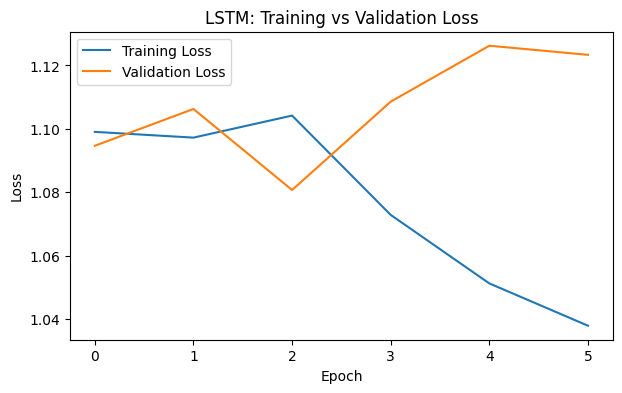


LSTM Accuracy: 0.1205

Classification Report:
              precision    recall  f1-score   support

    negative       0.30      0.01      0.02       643
     neutral       0.11      0.98      0.19       437
    positive       0.82      0.02      0.04      3019

    accuracy                           0.12      4099
   macro avg       0.41      0.34      0.08      4099
weighted avg       0.66      0.12      0.05      4099



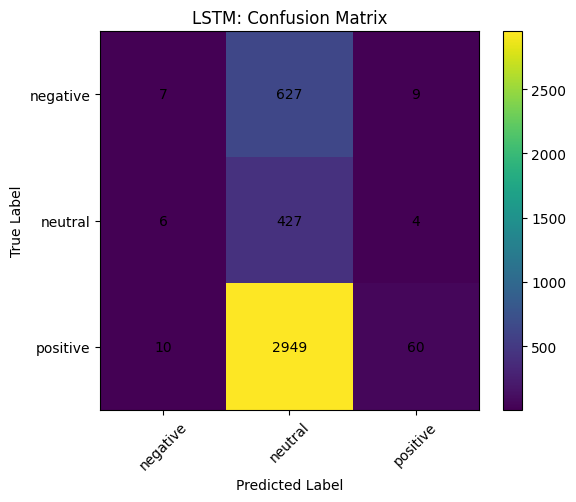

Training time seconds: 31.18


In [32]:
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

start = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)
lstm_time = time.time() - start

plot_history(lstm_history, 'LSTM')
lstm_acc, lstm_pred = evaluate_model(lstm_model, X_test, y_test, 'LSTM')
print('Training time seconds:', round(lstm_time, 2))


## 8. Model 3 - LSTM with pretrained Word2Vec/GloVe embeddings

This uses `glove-wiki-gigaword-50` from `gensim.downloader`. It is accepted here as a pretrained word embedding source for the Word2Vec-style embedding requirement.


In [33]:
import gensim.downloader as api

print('Loading pretrained GloVe vectors. This may take a few minutes the first time.')
embedding_model = api.load('glove-wiki-gigaword-50')
PRETRAINED_DIM = 50

word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, PRETRAINED_DIM))
matched_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        matched_words += 1

coverage = matched_words / vocab_size
print(f'Matched words: {matched_words}/{vocab_size} ({coverage:.2%})')


Loading pretrained GloVe vectors. This may take a few minutes the first time.
[==================================================] 100.0% 66.0/66.0MB downloaded
Matched words: 17246/20000 (86.23%)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4665 - loss: 1.0988 - val_accuracy: 0.1052 - val_loss: 1.0932 - learning_rate: 0.0010
Epoch 2/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4653 - loss: 1.0966 - val_accuracy: 0.1086 - val_loss: 1.1115 - learning_rate: 0.0010
Epoch 3/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3221 - loss: 1.0954 - val_accuracy: 0.1089 - val_loss: 1.1052 - learning_rate: 5.0000e-04


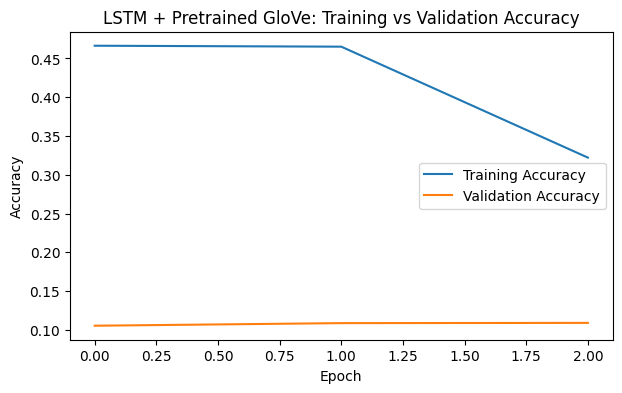

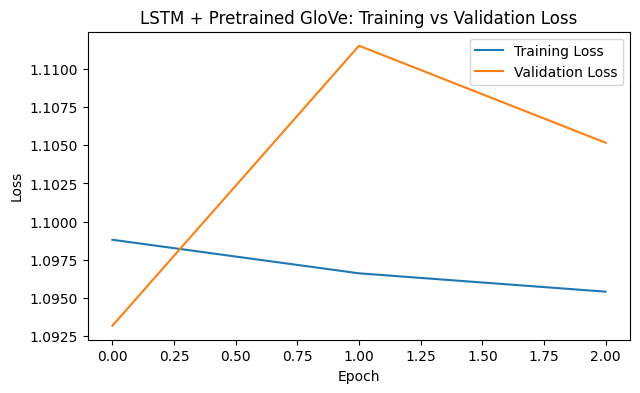


LSTM + Pretrained GloVe Accuracy: 0.1066

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       643
     neutral       0.11      1.00      0.19       437
    positive       0.00      0.00      0.00      3019

    accuracy                           0.11      4099
   macro avg       0.04      0.33      0.06      4099
weighted avg       0.01      0.11      0.02      4099



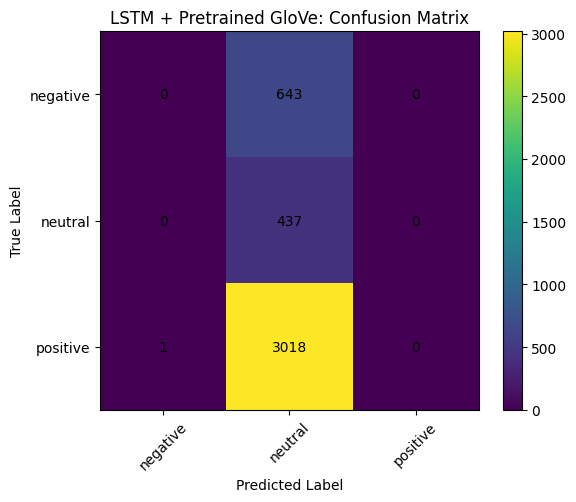

Training time seconds: 11.58


In [34]:
def build_lstm_glove_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),
        LSTM(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

glove_lstm_model = build_lstm_glove_model()
glove_lstm_model.summary()

start = time.time()
glove_history = glove_lstm_model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)
glove_time = time.time() - start

plot_history(glove_history, 'LSTM + Pretrained GloVe')
glove_acc, glove_pred = evaluate_model(glove_lstm_model, X_test, y_test, 'LSTM + Pretrained GloVe')
print('Training time seconds:', round(glove_time, 2))


## 9. Compare model performance

,Model,Test Accuracy,Training Time (seconds)
0,Simple RNN,0.386436,35.366972
1,LSTM,0.120517,31.182144
2,LSTM + Pretrained GloVe,0.106611,11.583964


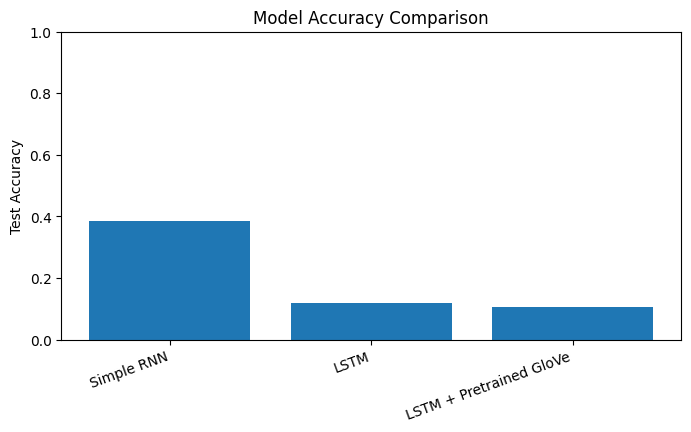

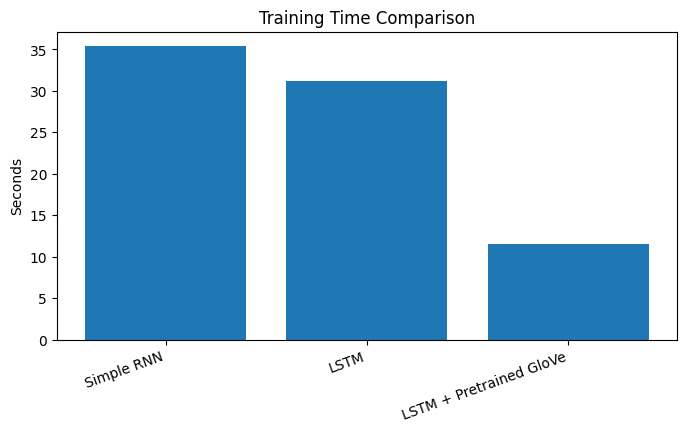

In [35]:
results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Pretrained GloVe'],
    'Test Accuracy': [rnn_acc, lstm_acc, glove_acc],
    'Training Time (seconds)': [rnn_time, lstm_time, glove_time]
})

display(results.sort_values(by='Test Accuracy', ascending=False))

plt.figure(figsize=(8,4))
plt.bar(results['Model'], results['Test Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(results['Model'], results['Training Time (seconds)'])
plt.title('Training Time Comparison')
plt.ylabel('Seconds')
plt.xticks(rotation=20, ha='right')
plt.show()


## 10. Error analysis

In [37]:
# Select the best model automatically based on test accuracy.
model_objects = {
    'Simple RNN': (rnn_model, rnn_pred, rnn_acc),
    'LSTM': (lstm_model, lstm_pred, lstm_acc),
    'LSTM + Pretrained GloVe': (glove_lstm_model, glove_pred, glove_acc)
}

best_model_name = max(model_objects, key=lambda name: model_objects[name][2])
best_model, best_pred, best_acc = model_objects[best_model_name]

print('Best model:', best_model_name, 'Accuracy:', round(best_acc, 4))

# Build a dataframe for test predictions.
error_df = pd.DataFrame({
    'clean_review': X_test_text,
    'actual': label_encoder.inverse_transform(y_test),
    'predicted': label_encoder.inverse_transform(best_pred)
})

misclassified = error_df[error_df['actual'] != error_df['predicted']].copy()

print('Total misclassified examples:', len(misclassified))
display(misclassified.head(3))

print('\nPossible error reasons to discuss in the report:')
print('1. Neutral reviews often contain mixed positive and negative words, making them harder to classify.')
print('2. The dataset is imbalanced, with many more positive reviews than neutral or negative reviews.')
print('3. Some reviews are long and contain multiple opinions, but padding/truncation may remove useful context.')
print('4. RNN/LSTM models may struggle with sarcasm, implicit meaning, and domain-specific expressions.')

Best model: Simple RNN Accuracy: 0.3864
Total misclassified examples: 2515


,clean_review,actual,predicted
1,basic expect luxury place stay room small gene...,neutral,positive
2,perfect recommend place great location friendl...,positive,negative
3,aqua palm big disappointment stopped hawaii wa...,neutral,positive



Possible error reasons to discuss in the report:
1. Neutral reviews often contain mixed positive and negative words, making them harder to classify.
2. The dataset is imbalanced, with many more positive reviews than neutral or negative reviews.
3. Some reviews are long and contain multiple opinions, but padding/truncation may remove useful context.
4. RNN/LSTM models may struggle with sarcasm, implicit meaning, and domain-specific expressions.


## 11. Real-time prediction function

In [38]:
def predict_sentiment(text, model=best_model):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(np.max(probs))
    return pred_label, confidence

sample_text = 'The hotel room was clean and the staff were very friendly, but the breakfast was average.'
print(predict_sentiment(sample_text))


('positive', 0.3556734323501587)


## 12. Optional GUI using Gradio

In [ ]:
import gradio as gr

def gradio_predict(review):
    label, confidence = predict_sentiment(review)
    return f'Predicted sentiment: {label} | Confidence: {confidence:.2%}'

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=5, label='Enter a hotel review'),
    outputs=gr.Textbox(label='Prediction'),
    title='Hotel Review Sentiment Classifier',
    description='Enter a hotel review and the trained model will predict whether it is negative, neutral, or positive.'
)

interface.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://367cf96ab7c53805fe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. Save the best model and preprocessing objects

In [ ]:
import pickle

best_model.save('/content/best_hotel_sentiment_model.keras')

with open('/content/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open('/content/preprocessing_config.pkl', 'wb') as f:
    pickle.dump({'MAX_LEN': MAX_LEN, 'class_names': class_names, 'best_model_name': best_model_name}, f)

print('Saved best model and preprocessing objects.')
